# Naive Bayes — Churn Prediction Model

Training a Gaussian Naive Bayes classifier on the churn dataset.
NB is extremely fast and works well when features are roughly
independent — good probabilistic baseline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## 1 · Data Loading & Prep

Dropping features that leak the churn outcome:

| Feature | Why it leaks |
|:--------|:-------------|
| `Total_Net_Paid` | Churned = 0 (didn't pay — set after churn) |
| `price_change_pct/abs` | Derived from Total_Net_Paid |
| `net_paid_vs_last` | Ratio involving current payment (0 for churned) |
| `Payment_Method` | Set to UNKNOWN after churn |
| `Payment_Timeframe` | All churned = 0 |
| `Days_To_Close_Post_Renewal` | Uses close date (post-outcome) |
| `Total_Renewal_Score_New` | Composite encodes outcome |

In [2]:
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

df = pd.read_csv(project_root / "data" / "processed" / "model_ready_dataset.csv")
print(f"Loaded shape: {df.shape}")

df = df[df["Prospect_Outcome"].isin(["Won", "Churned"])].copy()
df["target"] = (df["Prospect_Outcome"] == "Churned").astype(int)
df.drop(columns=["Prospect_Outcome"], inplace=True)

# ---- DROP LEAKY FEATURES ------------------------------------------------
leaky_cols = [
    "Total_Net_Paid", "price_change_pct", "price_change_abs",
    "net_paid_vs_last", "Payment_Method", "Payment_Timeframe",
    "Days_To_Close_Post_Renewal", "Total_Renewal_Score_New",
    "Renewal_Year",
]
df.drop(columns=leaky_cols, inplace=True, errors="ignore")
print(f"Dropped {len(leaky_cols)} leaky/non-predictive features")

# encode categoricals
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Churn rate: {y_train.mean():.2%}")

Loaded shape: (122082, 61)
Dropped 9 leaky/non-predictive features

Features: 51
Train: 91115, Test: 22779
Churn rate: 11.12%


## 2 · Feature Scaling

GaussianNB assumes features follow a gaussian distribution.
Scaling helps the variance estimates be more comparable.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done")

Scaling done


## 3 · Baseline Naive Bayes

In [4]:
nb_base = GaussianNB()
nb_base.fit(X_train_scaled, y_train)

y_pred_base = nb_base.predict(X_test_scaled)
y_prob_base = nb_base.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("BASELINE NAIVE BAYES RESULTS")
print("=" * 60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_base):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob_base):.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=["Won", "Churned"]))

BASELINE NAIVE BAYES RESULTS
Accuracy  : 0.8778
Precision : 0.4578
Recall    : 0.5355
F1 Score  : 0.4936
ROC AUC   : 0.8876

              precision    recall  f1-score   support

         Won       0.94      0.92      0.93     20245
     Churned       0.46      0.54      0.49      2534

    accuracy                           0.88     22779
   macro avg       0.70      0.73      0.71     22779
weighted avg       0.89      0.88      0.88     22779



## 4 · Hyperparameter Tuning

GaussianNB only has one tunable param: `var_smoothing`.
It controls how much variance is added to avoid zero-division.
NB is so fast this takes a few seconds.

In [5]:
smoothing_values = [1e-12, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
best_f1 = 0
best_smooth = None

results = []
for vs in smoothing_values:
    model = GaussianNB(var_smoothing=vs)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_strat, scoring="f1")
    mean_f1 = scores.mean()
    results.append((vs, mean_f1, scores.std()))
    print(f"var_smoothing={vs:.0e}: F1={mean_f1:.4f} (+/- {scores.std():.4f})")
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_smooth = vs

print(f"\nBest var_smoothing: {best_smooth:.0e}  ->  F1={best_f1:.4f}")

var_smoothing=1e-12: F1=0.4902 (+/- 0.0115)
var_smoothing=1e-10: F1=0.4902 (+/- 0.0115)
var_smoothing=1e-09: F1=0.4902 (+/- 0.0115)
var_smoothing=1e-08: F1=0.4902 (+/- 0.0115)
var_smoothing=1e-07: F1=0.4902 (+/- 0.0115)
var_smoothing=1e-06: F1=0.4902 (+/- 0.0115)
var_smoothing=1e-05: F1=0.4902 (+/- 0.0115)
var_smoothing=1e-04: F1=0.4901 (+/- 0.0115)
var_smoothing=1e-03: F1=0.4901 (+/- 0.0116)
var_smoothing=1e-02: F1=0.4871 (+/- 0.0126)

Best var_smoothing: 1e-12  ->  F1=0.4902


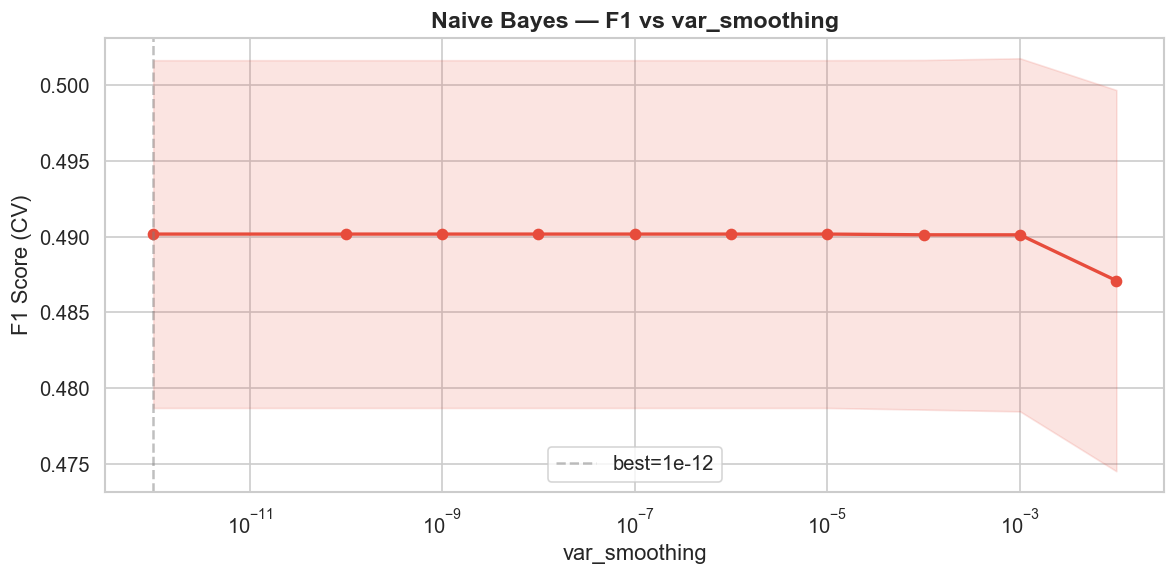

In [6]:
# plot the F1 vs var_smoothing
res_df = pd.DataFrame(results, columns=["var_smoothing", "f1_mean", "f1_std"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(res_df["var_smoothing"], res_df["f1_mean"], "o-", color="#e74c3c", linewidth=2)
ax.fill_between(res_df["var_smoothing"],
                res_df["f1_mean"] - res_df["f1_std"],
                res_df["f1_mean"] + res_df["f1_std"],
                alpha=0.15, color="#e74c3c")
ax.set_xlabel("var_smoothing")
ax.set_ylabel("F1 Score (CV)")
ax.set_title("Naive Bayes — F1 vs var_smoothing", fontsize=14, fontweight="bold")
ax.axvline(x=best_smooth, color="gray", linestyle="--", alpha=0.5, label=f"best={best_smooth:.0e}")
ax.legend()
plt.tight_layout()
plt.show()

## 5 · Best Model Evaluation

In [7]:
best_nb = GaussianNB(var_smoothing=best_smooth)
best_nb.fit(X_train_scaled, y_train)

y_pred = best_nb.predict(X_test_scaled)
y_prob = best_nb.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("TUNED NAIVE BAYES RESULTS")
print("=" * 60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Won", "Churned"]))

TUNED NAIVE BAYES RESULTS
Accuracy  : 0.8778
Precision : 0.4578
Recall    : 0.5355
F1 Score  : 0.4936
ROC AUC   : 0.8876

              precision    recall  f1-score   support

         Won       0.94      0.92      0.93     20245
     Churned       0.46      0.54      0.49      2534

    accuracy                           0.88     22779
   macro avg       0.70      0.73      0.71     22779
weighted avg       0.89      0.88      0.88     22779



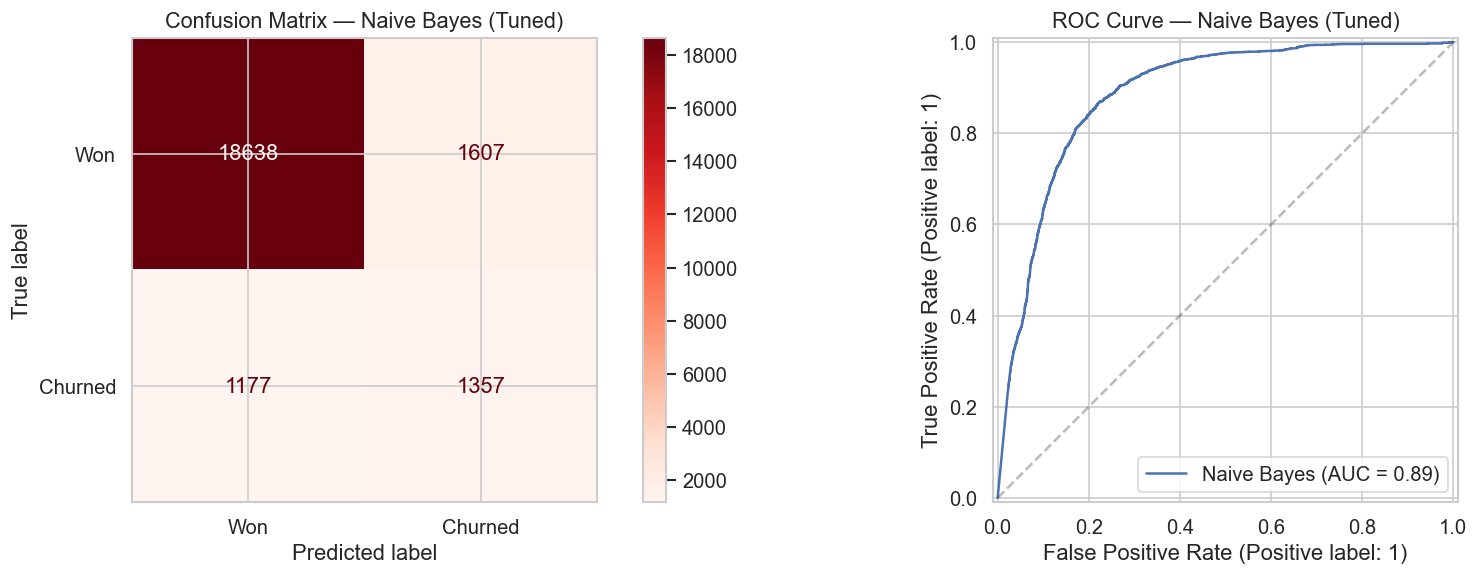

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Won", "Churned"], ax=axes[0],
    cmap="Reds"
)
axes[0].set_title("Confusion Matrix — Naive Bayes (Tuned)", fontsize=13)

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name="Naive Bayes")
axes[1].set_title("ROC Curve — Naive Bayes (Tuned)", fontsize=13)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)

plt.tight_layout()
plt.show()

## 6 · Class Priors & Per-Feature Analysis

Learned class priors:
  Won:     0.8888
  Churned: 0.1112



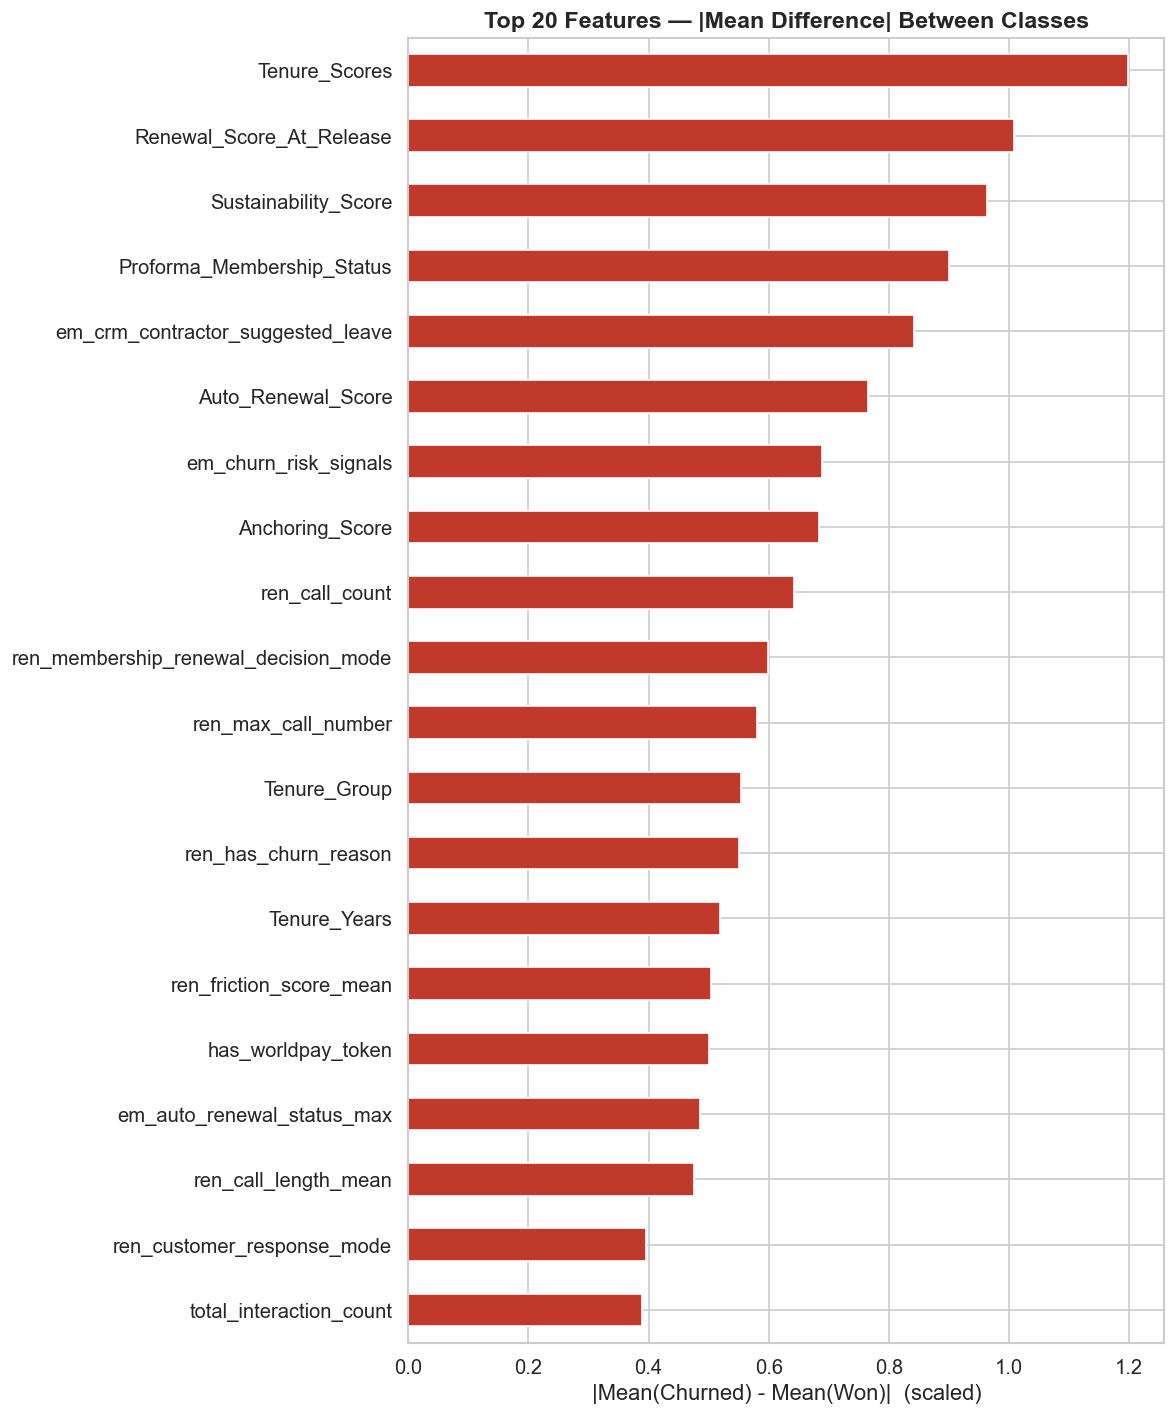

In [9]:
print("Learned class priors:")
print(f"  Won:     {best_nb.class_prior_[0]:.4f}")
print(f"  Churned: {best_nb.class_prior_[1]:.4f}")
print()

# which features have the biggest difference in means between classes?
mean_diff = np.abs(best_nb.theta_[1] - best_nb.theta_[0])  # |mean_churned - mean_won|
feat_diff = pd.Series(mean_diff, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
feat_diff.tail(20).plot.barh(ax=ax, color="#c0392b", edgecolor="white")
ax.set_title("Top 20 Features — |Mean Difference| Between Classes", fontsize=14, fontweight="bold")
ax.set_xlabel("|Mean(Churned) - Mean(Won)|  (scaled)")
plt.tight_layout()
plt.show()

## Summary

| Metric | Baseline | Tuned |
|:-------|:---------|:------|
| Accuracy | — | — |
| Precision | — | — |
| Recall | — | — |
| F1 Score | — | — |
| ROC AUC | — | — |

*(Fill in after running the notebook)*

Naive Bayes assumes feature independence — which is violated
here (many correlated features). Expect lower accuracy than
tree-based models, but NB often gives surprisingly good recall
since it produces well-spread probability estimates.